# Task 3

## Calculating Logical Coupling and Visualization

This section computes the logical coupling between Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.

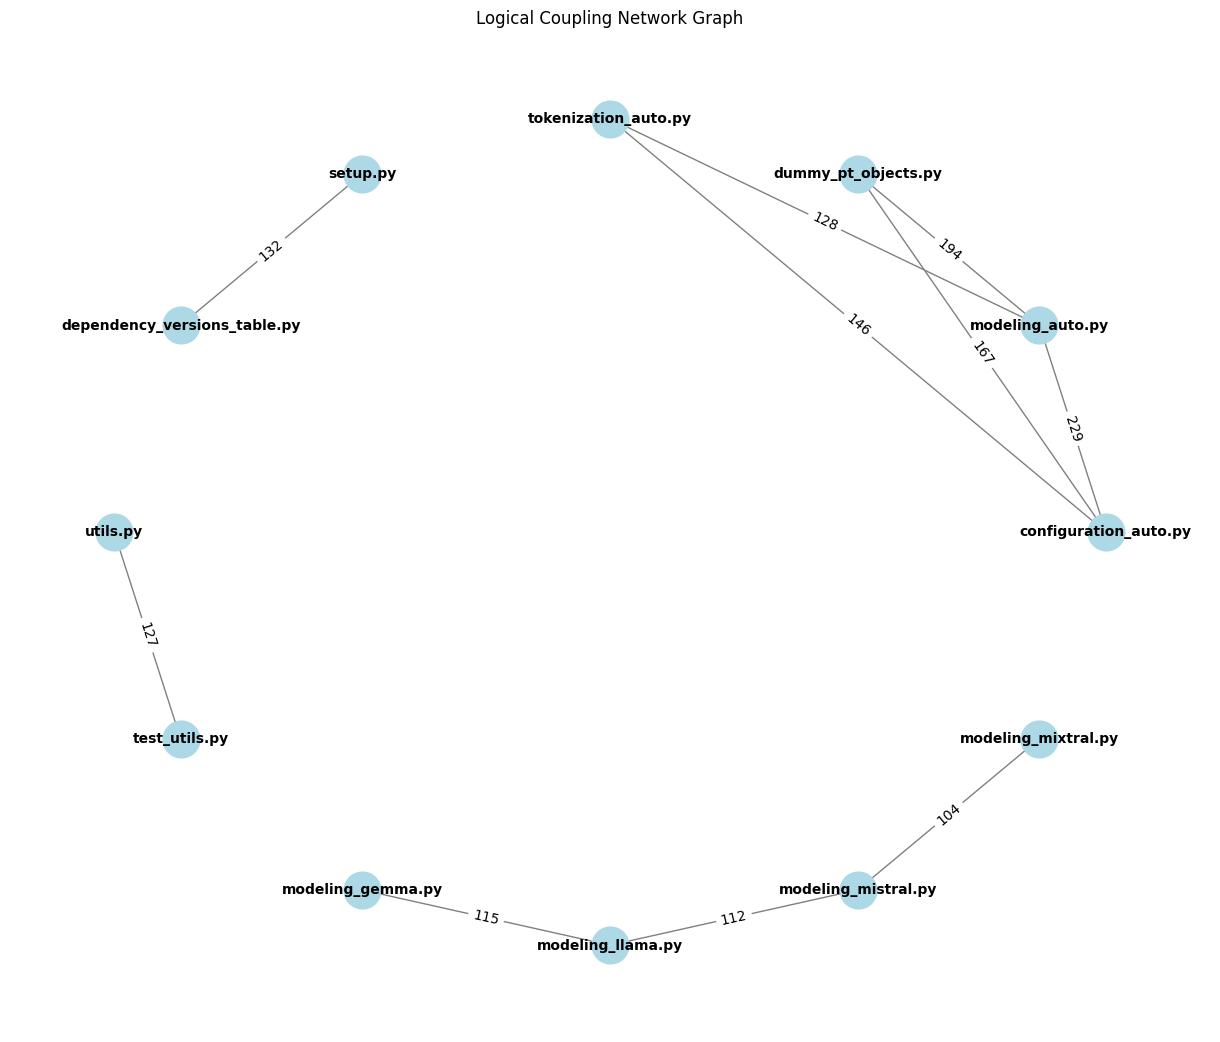

In [22]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph


REPOSITORY = "" #local URL to cloned repo, checkout tag v4.57.0
DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files if file.new_path and file.new_path.endswith('.py') and os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        file_pair_coupling.update([tuple(sorted(pair)) for pair in file_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_names = [(os.path.basename(pair[0]), os.path.basename(pair[1]), count) for pair, count in top_10_pairs]

plot_network_graph(top_10_names)


## Analyzing Coupling Between Test and Non-Test Files

This section computes the logical coupling between test files (files starting with `test_`) and non-test Python files in the repository based on their co-modification in commits since January 1, 2023. Non-Python files and `__init__.py` files are excluded from the analysis.

The top 10 most coupled file pairs are visualized using a network graph, where nodes represent files and edges indicate the strength of their coupling.


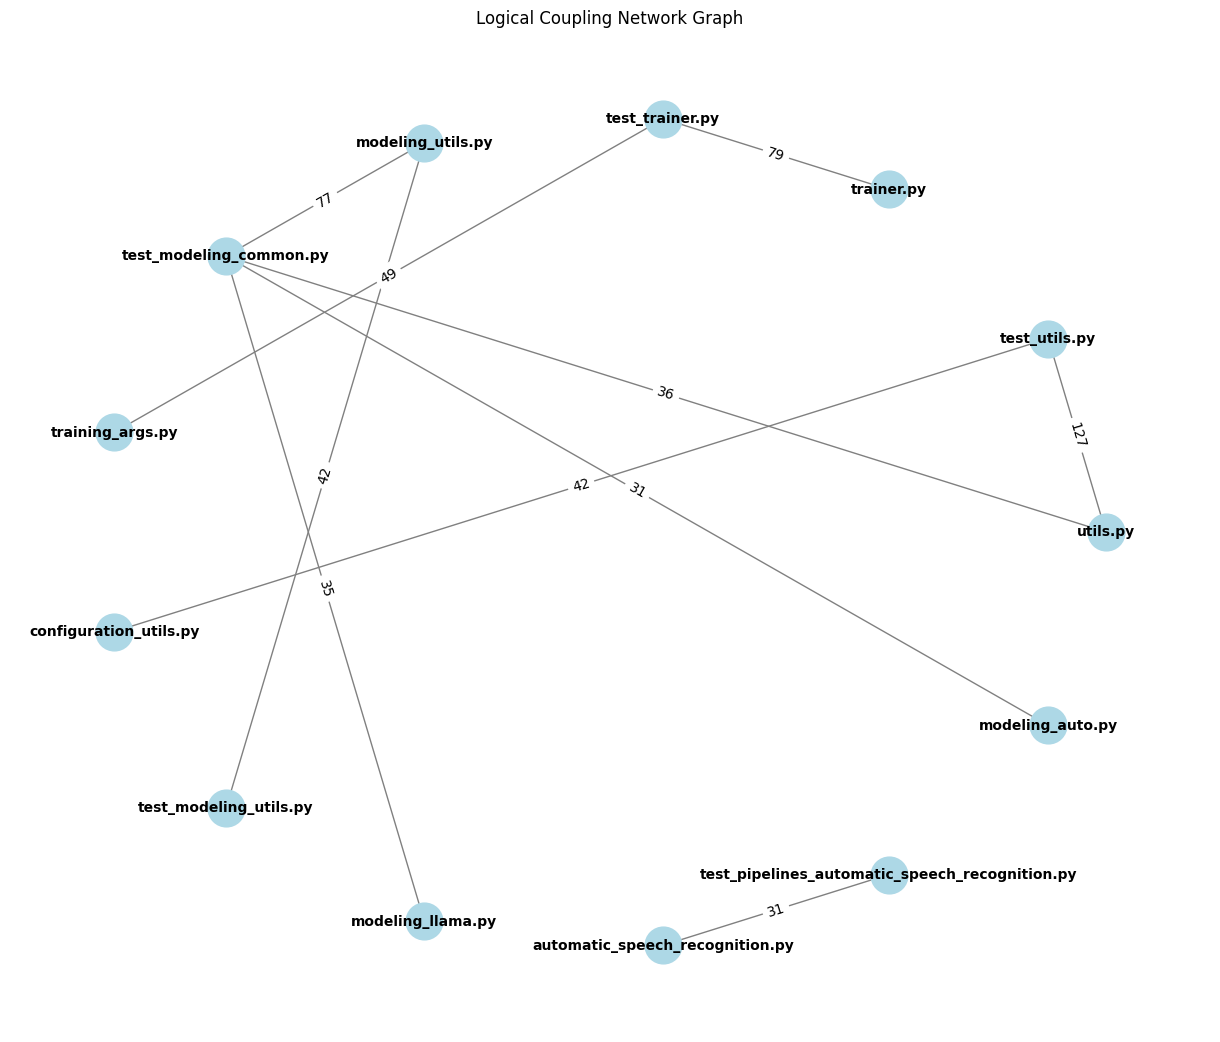

In [23]:
from datetime import datetime
from pydriller import Repository
from collections import Counter
import itertools
import os
from utils import plot_network_graph

REPOSITORY = "" #local URL to cloned repo, checkout tag v4.57.0
DATE = datetime(2023, 1, 1)

def calculate_logical_coupling(repository, since_date):
    file_pair_coupling = Counter()

    for commit in Repository(repository, since=since_date).traverse_commits():
        # Consider only Python files for coupling analysis, __init__.py files are excluded
        modified_files = [
            file.new_path for file in commit.modified_files if file.new_path and file.new_path.endswith('.py') and os.path.basename(file.new_path) != "__init__.py"
        ]
        # Commit requires at least two modified files to form a pair
        if len(modified_files) < 2:
            continue

        file_pairs = itertools.combinations(modified_files, 2)
        test_pairs = [
            pair for pair in file_pairs
            if (os.path.basename(pair[0]).startswith('test_') and not os.path.basename(pair[1]).startswith('test_')) or
               (os.path.basename(pair[1]).startswith('test_') and not os.path.basename(pair[0]).startswith('test_'))
        ]
        file_pair_coupling.update([tuple(sorted(pair)) for pair in test_pairs])

    return file_pair_coupling

calculated_coupling = calculate_logical_coupling(REPOSITORY, DATE) # This might take a while
top_10_pairs = calculated_coupling.most_common(10)
top_10_names = [(os.path.basename(pair[0]), os.path.basename(pair[1]), count) for pair, count in top_10_pairs]

plot_network_graph(top_10_names)